# 🗄️ Actividad 08 — Diseño e Implementación del Data Warehouse (PostgreSQL 16)
**DB:** `limon_analytics_db` | **Arquitectura:** Star Schema v2.0 (5 Dimensiones)

Implementamos la estructura física del Data Warehouse utilizando un **Star Schema puro** para garantizar la escalabilidad analítica.

In [1]:
%matplotlib inline
import os, sys, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; PROCESSED=DIRS['processed']
REPORTS=DIRS['reports']; PG_URI=CFG['PG_URI']
print(f"✅ Setup OK | {os.getcwd()}")

✅ Setup OK | C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## 8.1 Verificar/Crear Base de Datos

In [2]:

PG_BASE = PG_URI.rsplit('/', 1)[0] + '/postgres'
try:
    engine_base = create_engine(PG_BASE, isolation_level='AUTOCOMMIT')
    with engine_base.connect() as conn:
        exists = conn.execute(text("SELECT 1 FROM pg_database WHERE datname='limon_analytics_db'")).fetchone()
        if not exists:
            conn.execute(text("CREATE DATABASE limon_analytics_db ENCODING 'UTF8'"))
            print("  ✅ Base de datos limon_analytics_db CREADA.")
        else:
            print("  ✅ Base de datos limon_analytics_db ya existe.")
    engine_base.dispose()
except Exception as e:
    print(f"  ❌ Error: {e}")


  ✅ Base de datos limon_analytics_db ya existe.


## 8.2 Arquitectura del Star Schema (Diagrama Técnico)

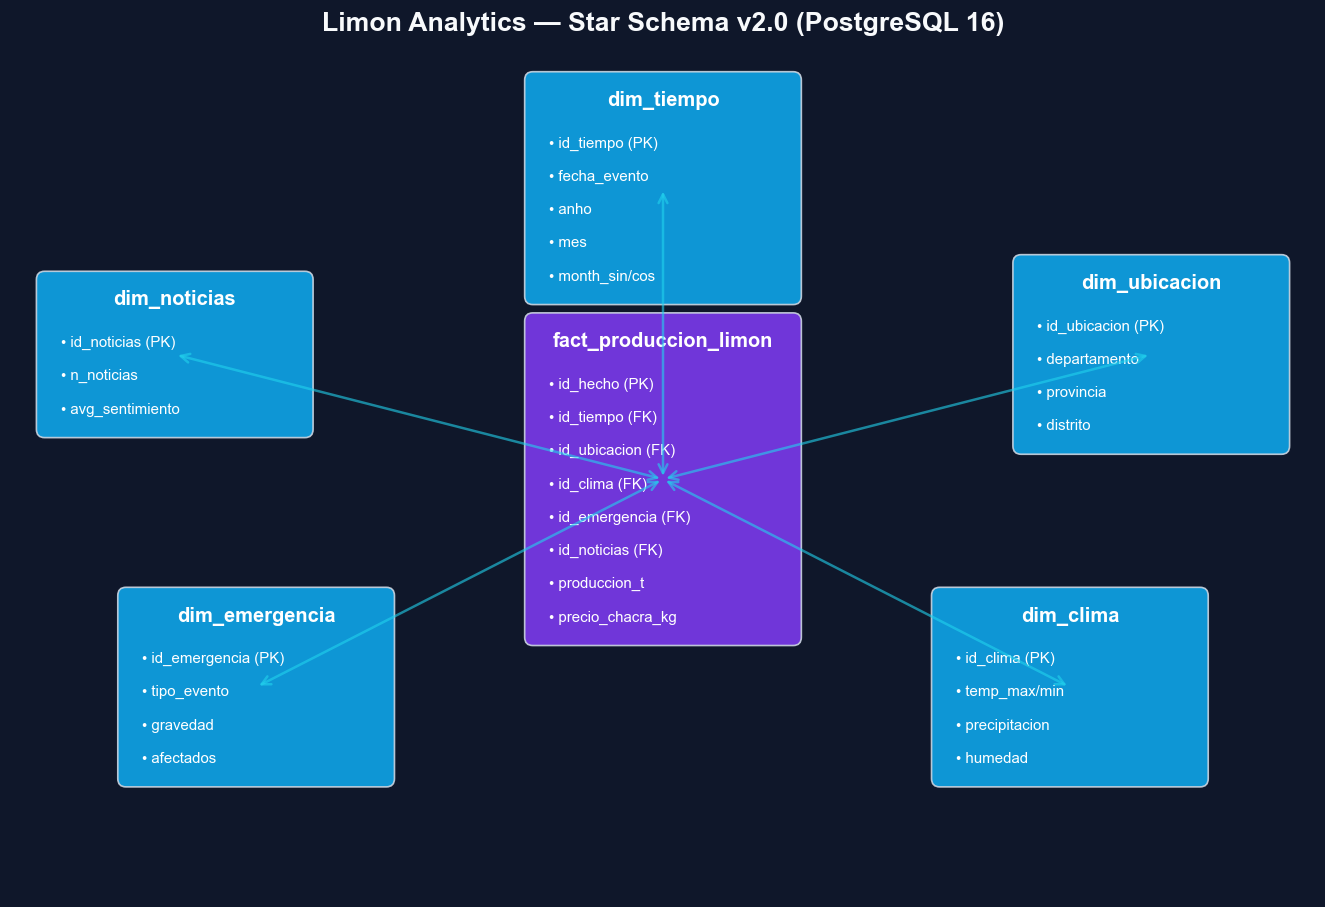

In [3]:

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 16); ax.set_ylim(0, 10); ax.axis('off')
fig.patch.set_facecolor('#0f172a')

def draw_table(ax, x, y, title, columns, color='#0ea5e9'):
    width, height = 3.2, len(columns) * 0.4 + 0.6
    rect = mpatches.FancyBboxPatch((x-width/2, y-height/2), width, height, 
                                   boxstyle="round,pad=0.1", ec="#cbd5e1", fc=color, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x, y + height/2 - 0.3, title, weight='bold', color='white', ha='center', size=12)
    for i, col in enumerate(columns):
        ax.text(x - width/2 + 0.2, y + height/2 - 0.8 - i*0.4, f"• {col}", color='white', size=9)

fx, fy = 8, 5
draw_table(ax, fx, fy, "fact_produccion_limon", 
           ["id_hecho (PK)", "id_tiempo (FK)", "id_ubicacion (FK)", "id_clima (FK)", 
            "id_emergencia (FK)", "id_noticias (FK)", "produccion_t", "precio_chacra_kg"], 
           color='#7c3aed')

dims = [
    (8, 8.5, "dim_tiempo", ["id_tiempo (PK)", "fecha_evento", "anho", "mes", "month_sin/cos"]),
    (14, 6.5, "dim_ubicacion", ["id_ubicacion (PK)", "departamento", "provincia", "distrito"]),
    (13, 2.5, "dim_clima", ["id_clima (PK)", "temp_max/min", "precipitacion", "humedad"]),
    (3, 2.5, "dim_emergencia", ["id_emergencia (PK)", "tipo_evento", "gravedad", "afectados"]),
    (2, 6.5, "dim_noticias", ["id_noticias (PK)", "n_noticias", "avg_sentimiento"])
]

for dx, dy, dtitle, dcols in dims:
    draw_table(ax, dx, dy, dtitle, dcols)
    ax.annotate("", xy=(fx, fy), xytext=(dx, dy),
                arrowprops=dict(arrowstyle="<->", color="#22d3ee", lw=1.5, alpha=0.6))

plt.title("Limon Analytics — Star Schema v2.0 (PostgreSQL 16)", color='#f8fafc', size=16, weight='bold', pad=20)
plt.show()


## 8.3 Despliegue Físico (DDL SQL)

In [4]:

STMTS = [
    "DROP TABLE IF EXISTS fact_produccion_limon CASCADE",
    "DROP TABLE IF EXISTS dim_tiempo CASCADE",
    "DROP TABLE IF EXISTS dim_ubicacion CASCADE",
    "DROP TABLE IF EXISTS dim_clima CASCADE",
    "DROP TABLE IF EXISTS dim_emergencia CASCADE",
    "DROP TABLE IF EXISTS dim_noticias CASCADE",

    "CREATE TABLE dim_tiempo (id_tiempo SERIAL PRIMARY KEY, fecha_evento VARCHAR(7) UNIQUE NOT NULL, anho SMALLINT, mes SMALLINT, month_sin FLOAT, month_cos FLOAT)",
    "CREATE TABLE dim_ubicacion (id_ubicacion SERIAL PRIMARY KEY, departamento VARCHAR(60), provincia VARCHAR(60), distrito VARCHAR(60), UNIQUE(departamento, provincia, distrito))",
    "CREATE TABLE dim_clima (id_clima SERIAL PRIMARY KEY, temp_max_c FLOAT, temp_min_c FLOAT, precipitacion_mm FLOAT)",
    "CREATE TABLE dim_emergencia (id_emergencia SERIAL PRIMARY KEY, tipo_emergencia VARCHAR(100), num_emergencias INT)",
    "CREATE TABLE dim_noticias (id_noticias SERIAL PRIMARY KEY, n_noticias INT, avg_sentimiento FLOAT)",
    "CREATE TABLE fact_produccion_limon (id_hecho SERIAL PRIMARY KEY, id_tiempo INT REFERENCES dim_tiempo(id_tiempo), id_ubicacion INT REFERENCES dim_ubicacion(id_ubicacion), id_clima INT REFERENCES dim_clima(id_clima), id_emergencia INT REFERENCES dim_emergencia(id_emergencia), id_noticias INT REFERENCES dim_noticias(id_noticias), produccion_t FLOAT, precio_chacra_kg FLOAT)"
]

try:
    engine = create_engine(PG_URI)
    with engine.connect() as conn:
        for stmt in STMTS:
            conn.execute(text(stmt))
            conn.commit()
    print("✅ Star Schema de 5 Dimensiones desplegado exitosamente.")
except Exception as e:
    print(f"❌ Error al crear tablas: {e}")


✅ Star Schema de 5 Dimensiones desplegado exitosamente.


## 8.4 Simulación y Validación de la Estructura de Datos
Visualizamos una muestra simulada de cómo se verán los datos dentro de cada una de las 5 dimensiones y la tabla de hechos.

In [5]:

print("--- [DIM_TIEMPO] ---")
df_t = pd.DataFrame({
    'id_tiempo': [1, 2, 3], 'fecha_evento': ['2021-01', '2021-02', '2021-03'],
    'anho': [2021, 2021, 2021], 'mes': [1, 2, 3],
    'month_sin': [0.5, 0.86, 1.0], 'month_cos': [0.86, 0.5, 0.0]
})
display(df_t)

print("\n--- [DIM_UBICACION] ---")
df_u = pd.DataFrame({
    'id_ubicacion': [1, 2], 'departamento': ['PIURA', 'PIURA'],
    'provincia': ['SULLANA', 'PIURA'], 'distrito': ['LANCONES', 'CASTILLA']
})
display(df_u)

print("\n--- [DIM_CLIMA (NASA)] ---")
df_c = pd.DataFrame({
    'id_clima': [101, 102], 'temp_max_c': [32.5, 34.1],
    'temp_min_c': [18.2, 19.5], 'precipitacion_mm': [0.5, 12.4]
})
display(df_c)

print("\n--- [DIM_EMERGENCIA (INDECI)] ---")
df_e = pd.DataFrame({
    'id_emergencia': [50, 51], 'tipo_emergencia': ['LLUVIAS INTENSAS', 'SIN EMERGENCIAS'],
    'num_emergencias': [3, 0]
})
display(df_e)

print("\n--- [DIM_NOTICIAS (AGRARIA.PE)] ---")
df_n = pd.DataFrame({
    'id_noticias': [1, 2], 'n_noticias': [15, 8], 'avg_sentimiento': [0.45, -0.12]
})
display(df_n)

print("\n--- [FACT_PRODUCCION_LIMON] (Central Hub) ---")
df_f = pd.DataFrame({
    'id_hecho': [1, 2], 'id_tiempo': [1, 2], 'id_ubicacion': [1, 1],
    'id_clima': [101, 102], 'id_emergencia': [50, 51], 'id_noticias': [1, 2],
    'produccion_t': [4500.5, 4200.0], 'precio_chacra_kg': [2.8, 3.1]
})
display(df_f)


--- [DIM_TIEMPO] ---


,id_tiempo,fecha_evento,anho,mes,month_sin,month_cos
0,1,2021-01,2021,1,0.50,0.86
1,2,2021-02,2021,2,0.86,0.50
2,3,2021-03,2021,3,1.00,0.00



--- [DIM_UBICACION] ---


,id_ubicacion,departamento,provincia,distrito
0,1,PIURA,SULLANA,LANCONES
1,2,PIURA,PIURA,CASTILLA



--- [DIM_CLIMA (NASA)] ---


...

,id_emergencia,tipo_emergencia,num_emergencias
0,50,LLUVIAS INTENSAS,3
1,51,SIN EMERGENCIAS,0



--- [DIM_NOTICIAS (AGRARIA.PE)] ---


,id_noticias,n_noticias,avg_sentimiento
0,1,15,0.45
1,2,8,-0.12



--- [FACT_PRODUCCION_LIMON] (Central Hub) ---


,id_hecho,id_tiempo,id_ubicacion,id_clima,id_emergencia,id_noticias,produccion_t,precio_chacra_kg
0,1,1,1,101,50,1,4500.5,2.8
1,2,2,1,102,51,2,4200.0,3.1


## 8.5 Conclusión\nEl esquema está listo para ser poblado por el pipeline ETL.